#  Ataques de Envenenamento de Dados em Modelos ML para e-Health

> **Baseado em:** *Prevention of Data Poisonous Threats on Machine Learning Models in e-Health*  
> Alruwaili & Moulahi — ACM Transactions on Computing for Healthcare, 2025

---

##  O que você vai experimentar:

Neste notebook você vai:
1. **Carregar** um dataset médico real (Breast Cancer ou Diabetes)
2. **Simular** um ataque de Label-Flipping com diferentes taxas
3. **Treinar** modelos de ML nos dados limpos e envenenados
4. **Visualizar** o impacto do envenenamento na acurácia
5. **Detectar** os dados envenenados com RF e GB

---
 **Execute as células uma por vez**, pois cada célula tem uma tarefa específica!

#### Célula 1 — Instalar **Dependências**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

# Estilo visual
plt.style.use('dark_background')
COLORS = {'RF': '#00D4FF', 'GB': '#7C3AED', 'LR': '#10B981', 'SVM': '#EF4444', 'MLP': '#F59E0B'}

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


#### Célula 3 — Carregar Dataset

**SUA VEZ:** Escolha o dataset que quer usar!





In [ ]:
# =====================================================
#  ESCOLHA O DATASET (descomente uma das linhas)
# =====================================================
DATASET = 'breast_cancer'   # 32 features — resultado melhor
# DATASET = 'diabetes'      # 9 features — mais desafiador
# =====================================================

if DATASET == 'breast_cancer':
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target)  # 0 = maligno, 1 = benigno
    print(f'   Dataset: Breast Cancer Wisconsin')
    print(f'   Features: {X.shape[1]} | Amostras: {X.shape[0]}')
    print(f'   Classes: {dict(y.value_counts().rename({0:"Maligno",1:"Benigno"}))}')

elif DATASET == 'diabetes':
    # Dataset Pima Indians Diabetes (similar ao do artigo)
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
    cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
    df = pd.read_csv(url, names=cols)
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']
    print(f'   Dataset: Pima Indians Diabetes')
    print(f'   Features: {X.shape[1]} | Amostras: {X.shape[0]}')
    print(f'   Classes: {dict(y.value_counts().rename({0:"Sem Diabetes",1:"Com Diabetes"}))}')

# Split treino/teste (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTreino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')

   Dataset: Breast Cancer Wisconsin
   Features: 30 | Amostras: 569
   Classes: {'Benigno': np.int64(357), 'Maligno': np.int64(212)}

Treino: 398 amostras | Teste: 171 amostras


####  Célula 4 — Simular o Ataque de Label-Flipping

**SUA VEZ:** Escolha a taxa de envenenamento!

   Ataque simulado com taxa de 25%
   Rótulos alterados: 99 de 398 amostras

   Distribuição ORIGINAL:  {1: np.int64(250), 0: np.int64(148)}
   Distribuição ENVENENADA: {1: np.int64(223), 0: np.int64(175)}


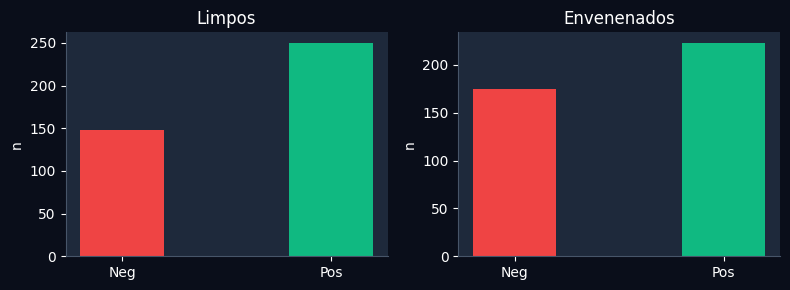

Ataque simulado!


In [ ]:
def label_flipping_attack(y_train, poison_rate):
    """
    Simula um ataque de Label-Flipping.
    Inverte aleatoriamente `poison_rate` dos rótulos de treino.
    Retorna os rótulos envenenados e uma máscara indicando quais foram alterados.
    """
    y_poisoned = y_train.copy()
    n_poison = int(len(y_train) * poison_rate)

    # Escolhe índices aleatórios para envenenar
    np.random.seed(42)
    poison_idx = np.random.choice(len(y_train), size=n_poison, replace=False)

    # Inverte os rótulos selecionados (0→1 ou 1→0)
    y_poisoned.iloc[poison_idx] = 1 - y_poisoned.iloc[poison_idx]

    # Máscara: 1 = envenenado, 0 = limpo
    poison_mask = np.zeros(len(y_train), dtype=int)
    poison_mask[poison_idx] = 1

    return y_poisoned, poison_mask


# =====================================================
#  ESCOLHA A TAXA DE ENVENENAMENTO
# =====================================================
POISON_RATE = 0.25   # Experimente: 0.05, 0.25, 0.50, 0.75
# =====================================================

y_train_poisoned, poison_mask = label_flipping_attack(pd.Series(y_train.values), POISON_RATE)

# Visualiza o impacto
n_flipped = poison_mask.sum()
print(f'   Ataque simulado com taxa de {POISON_RATE*100:.0f}%')
print(f'   Rótulos alterados: {n_flipped} de {len(y_train)} amostras')
print(f'\n   Distribuição ORIGINAL:  {dict(pd.Series(y_train.values).value_counts())}')
print(f'   Distribuição ENVENENADA: {dict(y_train_poisoned.value_counts())}')

# Mini visualização
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, (titulo, dados) in zip(axes, [('Limpos', y_train.values), ('Envenenados', y_train_poisoned.values)]):
    unique, counts = np.unique(dados, return_counts=True)
    ax.bar(['Neg', 'Pos'], counts, color=['#EF4444', '#10B981'], width=0.4)
    ax.set_title(titulo, fontsize=12, color='white')
    ax.set_ylabel('n', color='white')
    ax.tick_params(colors='white')
    ax.set_facecolor('#1E293B')
    fig.patch.set_facecolor('#0A0E1A')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_edgecolor('#475569')
plt.tight_layout()
plt.show()
print('Ataque simulado!')

#### Célula 5 — Treinar Modelos e Comparar

Treina os 5 modelos do artigo nos dados **limpos** e **envenenados** e compara os resultados.

In [ ]:
# Definição dos modelos (com parâmetros similares ao artigo)
models = {
    'LR':  LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=42),
    'GB':  GradientBoostingClassifier(n_estimators=100, random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
}

def avaliar_modelo(model, X_tr, y_tr, X_te, y_te):
    """Treina e avalia um modelo. Retorna as métricas."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Acurácia':  round(accuracy_score(y_te, y_pred), 4),
        'Precisão':  round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_te, y_pred, zero_division=0), 4),
    }

print(' Treinando modelos...\n')

results_clean    = {}
results_poisoned = {}

for name, model in models.items():
    import copy
    results_clean[name]    = avaliar_modelo(copy.deepcopy(model), X_train_sc, y_train,         X_test_sc, y_test)
    results_poisoned[name] = avaliar_modelo(copy.deepcopy(model), X_train_sc, y_train_poisoned, X_test_sc, y_test)
    print(f'  ✓ {name} treinado')

df_clean    = pd.DataFrame(results_clean).T
df_poisoned = pd.DataFrame(results_poisoned).T

print('\n DADOS LIMPOS:')
print(df_clean.to_string())
print(f'\n DADOS ENVENENADOS ({POISON_RATE*100:.0f}%):')
print(df_poisoned.to_string())

 Treinando modelos...

  ✓ LR treinado
  ✓ SVM treinado
  ✓ RF treinado
  ✓ GB treinado
  ✓ MLP treinado

 DADOS LIMPOS:
     Acurácia  Precisão  Recall  F1-Score
LR     0.9883    0.9907  0.9907    0.9907
SVM    0.9766    0.9813  0.9813    0.9813
RF     0.9357    0.9444  0.9533    0.9488
GB     0.9474    0.9455  0.9720    0.9585
MLP    0.9766    0.9905  0.9720    0.9811

 DADOS ENVENENADOS (25%):
     Acurácia  Precisão  Recall  F1-Score
LR     0.9181    0.9043  0.9720    0.9369
SVM    0.9532    0.9381  0.9907    0.9636
RF     0.9240    0.9434  0.9346    0.9390
GB     0.8830    0.9143  0.8972    0.9057
MLP    0.7661    0.8252  0.7944    0.8095


#### Célula 6 — Visualizar Queda de Performance

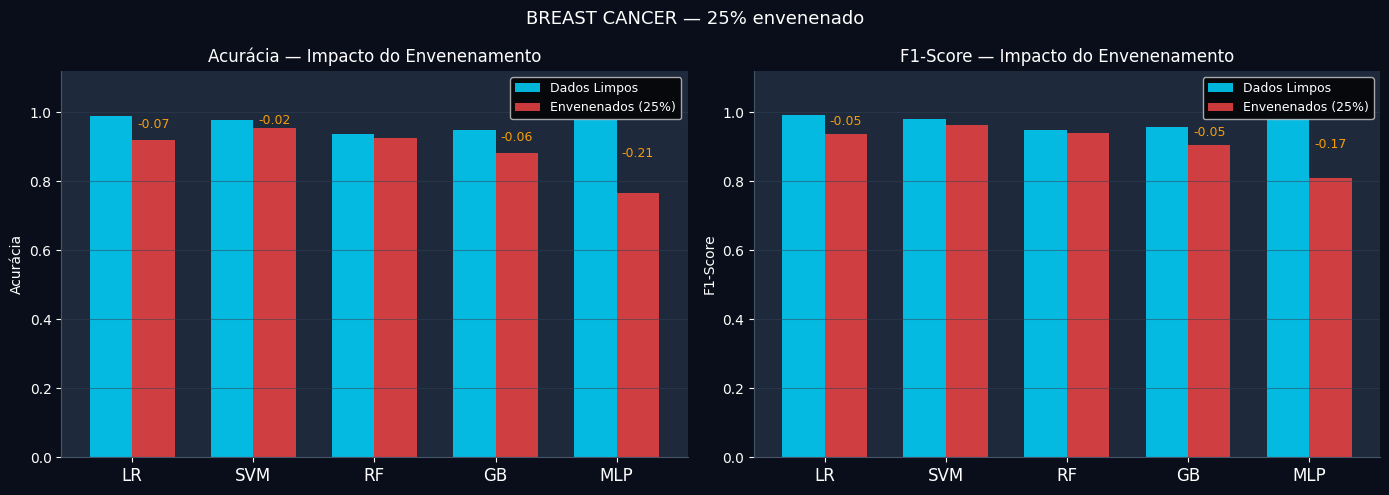

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0A0E1A')

model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.35

for ax, metric in zip(axes, ['Acurácia', 'F1-Score']):
    ax.set_facecolor('#1E293B')

    vals_clean    = [results_clean[m][metric] for m in model_names]
    vals_poisoned = [results_poisoned[m][metric] for m in model_names]

    ax.bar(x - width/2, vals_clean,    width, label='Dados Limpos',                    color='#00D4FF', alpha=0.85)
    ax.bar(x + width/2, vals_poisoned, width, label=f'Envenenados ({POISON_RATE*100:.0f}%)', color='#EF4444', alpha=0.85)

    for i, (c, p) in enumerate(zip(vals_clean, vals_poisoned)):
        if c - p > 0.02:
            ax.text(i + width/2, (c + p)/2, f'-{c-p:.2f}', color='#F59E0B', fontsize=9, ha='center')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, color='white', fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(metric, color='white')
    ax.set_title(f'{metric} — Impacto do Envenenamento', color='white', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.tick_params(axis='y', colors='white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_edgecolor('#475569')
    ax.yaxis.grid(True, color='#334155', alpha=0.5)

plt.suptitle(f'{DATASET.upper().replace("_", " ")} — {POISON_RATE*100:.0f}% envenenado', color='white', fontsize=13)
plt.tight_layout()
plt.show()

#### Célula 7 — Detectar Dados Envenenados com RF e GB


In [ ]:
print('Treinando detectores de envenenamento...')

# O problema agora é: dado um exemplo, é envenenado (1) ou limpo (0)?
# Usamos SMOTE para balancear as classes (técnica do artigo)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_sc, poison_mask)

print(f'   Antes do SMOTE: {dict(zip(*np.unique(poison_mask, return_counts=True)))}')
print(f'   Após SMOTE:     {dict(zip(*np.unique(y_smote, return_counts=True)))}')

# Split para detecção
X_det_train, X_det_test, y_det_train, y_det_test = train_test_split(
    X_smote, y_smote, test_size=0.3, random_state=42
)

# Treina RF e GB como detectores
detectors = {
    'RF (Detector)': RandomForestClassifier(n_estimators=100, random_state=42),
    'GB (Detector)': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

det_results = {}
for name, det in detectors.items():
    det.fit(X_det_train, y_det_train)
    y_pred = det.predict(X_det_test)
    det_results[name] = {
        'Acurácia': round(accuracy_score(y_det_test, y_pred), 4),
        'Precisão': round(precision_score(y_det_test, y_pred, zero_division=0), 4),
        'Recall':   round(recall_score(y_det_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_det_test, y_pred, zero_division=0), 4),
    }
    print(f'\n  {name}:')
    for k, v in det_results[name].items():
        print(f'     {k}: {v:.4f}')

Treinando detectores de envenenamento...
   Antes do SMOTE: {np.int64(0): np.int64(299), np.int64(1): np.int64(99)}
   Após SMOTE:     {np.int64(0): np.int64(299), np.int64(1): np.int64(299)}

  RF (Detector):
     Acurácia: 0.7778
     Precisão: 0.8333
     Recall: 0.7692
     F1-Score: 0.8000

  GB (Detector):
     Acurácia: 0.7389
     Precisão: 0.7822
     Recall: 0.7596
     F1-Score: 0.7707


#### Célula 8 — Curva de Degradação (todas as taxas)

Calculando curvas para todas as taxas (0%, 5%, 25%, 50%, 75%)
  ✓ Taxa 0% concluída
  ✓ Taxa 5% concluída
  ✓ Taxa 25% concluída
  ✓ Taxa 50% concluída
  ✓ Taxa 75% concluída


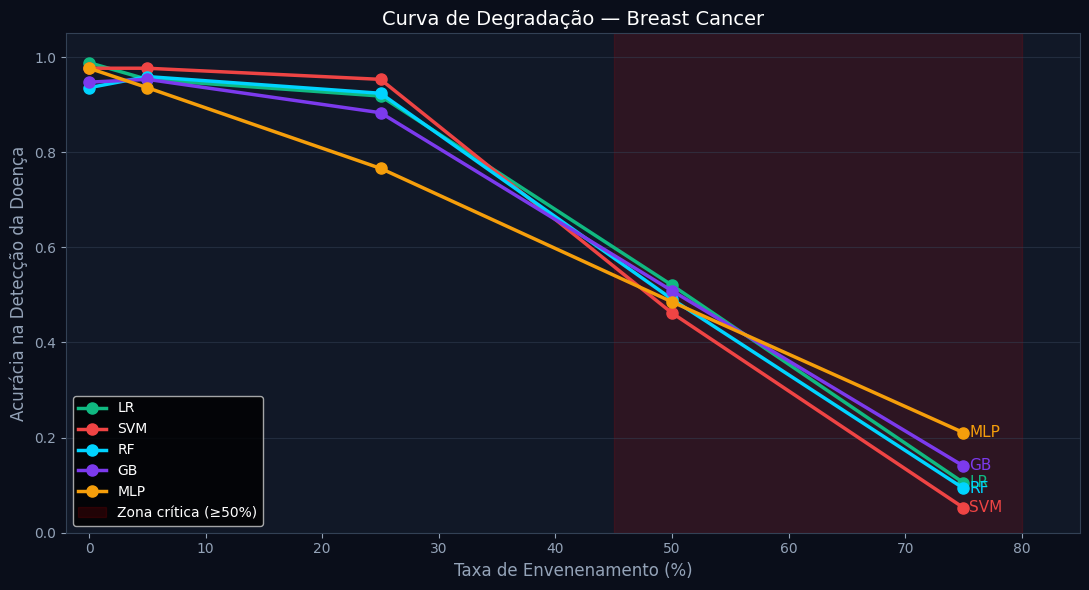

Note como RF e GB degradam mais lentamente — exatamente como no artigo!


In [ ]:
print('Calculando curvas para todas as taxas (0%, 5%, 25%, 50%, 75%)')
poison_rates = [0.0, 0.05, 0.25, 0.50, 0.75]
curve_data = {name: [] for name in models.keys()}

import copy
for rate in poison_rates:
    if rate == 0.0:
        y_tr = pd.Series(y_train.values)
    else:
        y_tr, _ = label_flipping_attack(pd.Series(y_train.values), rate)

    for name, model in models.items():
        m = copy.deepcopy(model)
        m.fit(X_train_sc, y_tr)
        acc = accuracy_score(y_test, m.predict(X_test_sc))
        curve_data[name].append(acc)
    print(f'  ✓ Taxa {rate*100:.0f}% concluída')

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0A0E1A')
ax.set_facecolor('#111827')

rates_pct = [r * 100 for r in poison_rates]
for name, accs in curve_data.items():
    ax.plot(rates_pct, accs, marker='o', linewidth=2.5, markersize=8,
            label=name, color=COLORS[name])
    ax.text(rates_pct[-1] + 0.5, accs[-1], name, color=COLORS[name], fontsize=11, va='center')

ax.axvspan(45, 80, alpha=0.12, color='red', label='Zona crítica (≥50%)')
ax.set_xlabel('Taxa de Envenenamento (%)', color='#94A3B8', fontsize=12)
ax.set_ylabel('Acurácia na Detecção da Doença', color='#94A3B8', fontsize=12)
ax.set_title(f'Curva de Degradação — {DATASET.replace("_", " ").title()}', color='white', fontsize=14)
ax.set_xlim(-2, 85)
ax.set_ylim(0, 1.05)
ax.tick_params(colors='#94A3B8')
ax.yaxis.grid(True, color='#334155', alpha=0.5)
ax.legend(loc='lower left', fontsize=10)
for spine in ax.spines.values(): spine.set_edgecolor('#334155')

plt.tight_layout()
plt.show()
print('Note como RF e GB degradam mais lentamente — exatamente como no artigo!')

#### Célula 9 — INTERATIVA: Teste Qualquer Taxa!

**Mude o valor de `MINHA_TAXA` e re-execute esta célula para ver o impacto em tempo real!**

In [ ]:
# =====================================================
#    MUDE ESTE VALOR E RE-EXECUTE A CÉLULA!
# =====================================================
MINHA_TAXA = 0.30   # Qualquer valor entre 0.0 e 0.90
MEUS_MODELOS = ['RF', 'GB']  # Quais modelos testar?
# =====================================================

import copy

y_minha, _ = label_flipping_attack(pd.Series(y_train.values), MINHA_TAXA)

print(f'Testando com taxa de envenenamento: {MINHA_TAXA*100:.0f}%\n')
print(f'{"Modelo":<8} {"Acurácia Limpa":>16} {"Acurácia Envenenada":>20} {"Queda":>8} {"Status":>12}')
print('-' * 70)

for name in MEUS_MODELOS:
    m_clean  = copy.deepcopy(models[name])
    m_poison = copy.deepcopy(models[name])

    m_clean.fit(X_train_sc, y_train)
    m_poison.fit(X_train_sc, y_minha)

    acc_c = accuracy_score(y_test, m_clean.predict(X_test_sc))
    acc_p = accuracy_score(y_test, m_poison.predict(X_test_sc))
    queda = acc_c - acc_p
    sinal = 'resistente' if queda < 0.05 else ('moderado' if queda < 0.15 else 'comprometido')

    print(f'{name:<8} {acc_c:>16.4f} {acc_p:>20.4f} {queda:>8.4f} {sinal:>12}')

print(f'\n  modelo resistente   — queda < 5%')
print(f'  modelo moderado     — queda 5–15%')
print(f'  modelo comprometido — queda > 15%')

Testando com taxa de envenenamento: 30%

Modelo     Acurácia Limpa  Acurácia Envenenada    Queda       Status
----------------------------------------------------------------------
RF                 0.9357               0.8830   0.0526     moderado
GB                 0.9474               0.8187   0.1287     moderado

  modelo resistente   — queda < 5%
  modelo moderado     — queda 5–15%
  modelo comprometido — queda > 15%


#### Célula 10 — Resumo Final

In [ ]:
print('=' * 60)
print('   RESUMO DO EXPERIMENTO')
print('=' * 60)
print(f'  Dataset:            {DATASET.replace("_", " ").title()}')
print(f'  Taxa testada:       {POISON_RATE*100:.0f}%')
print(f'  Amostras envenenadas: {int(len(y_train)*POISON_RATE)} de {len(y_train)}')
print()
print('   CONCLUSÕES DO ARTIGO (reproduzidas aqui):')
print('   RF e GB: melhores na detecção de envenenamento')
print('   LR e MLP: tendem a overgeneralizar (muitos falsos positivos)')
print('   SVM: colapsa rapidamente em breast cancer')
print('   SMOTE: essencial para detectar dados envenenados')
print('   GridSearch: otimizar parâmetros melhora os resultados')
print()
print('   DOI: https://doi.org/10.1145/3728369')
print('=' * 60)
print('   \n Experimento concluído! Obrigado por participar!')

   RESUMO DO EXPERIMENTO
  Dataset:            Breast Cancer
  Taxa testada:       25%
  Amostras envenenadas: 99 de 398

   CONCLUSÕES DO ARTIGO (reproduzidas aqui):
   RF e GB: melhores na detecção de envenenamento
   LR e MLP: tendem a overgeneralizar (muitos falsos positivos)
   SVM: colapsa rapidamente em breast cancer
   SMOTE: essencial para detectar dados envenenados
   GridSearch: otimizar parâmetros melhora os resultados

   DOI: https://doi.org/10.1145/3728369
   
 Experimento concluído! Obrigado por participar!
